In [2]:
import pandas as pd
import json
import glob
import os

# 1. Definir la ruta donde están los archivos
# Asumiendo que tu notebook está en 'notebooks/' y los datos en 'results/'
ruta_resultados = '../results' 

# 2. Encontrar todos los archivos de secretos
archivos_secretos = glob.glob(f"{ruta_resultados}/*_secrets.json")

datos_consolidados = []

# 3. Iterar sobre cada archivo y extraer los datos
for archivo in archivos_secretos:
    # Extraer el nombre del repositorio del nombre del archivo (ej: 'prefect_secrets.json' -> 'prefect')
    nombre_base = os.path.basename(archivo)
    repo_name = nombre_base.replace('_secrets.json', '')
    
    try:
        with open(archivo, 'r') as f:
            datos = json.load(f)
            
            # Si el archivo tiene datos (no está vacío)
            if datos:
                for secreto in datos:
                    # Añadir el nombre del repositorio al registro
                    secreto['Repository'] = repo_name
                    datos_consolidados.append(secreto)
    except Exception as e:
        print(f"Error procesando {archivo}: {e}")

# 4. Convertir a DataFrame
df = pd.DataFrame(datos_consolidados)

# 5. Seleccionar columnas relevantes
# Asegúrate de no incluir el secreto real en el CSV exportado
columnas_relevantes = ['Repository', 'RuleID', 'File', 'Commit', 'Author', 'Date']

# Verificar si el DataFrame no está vacío antes de guardar
if not df.empty:
    # Si alguna columna no existe en los datos, la ignoramos
    columnas_existentes = [col for col in columnas_relevantes if col in df.columns]
    df_limpio = df[columnas_existentes]
    
    # 6. Guardar como CSV
    ruta_csv = '../results/resumen_todos_secretos.csv'
    df_limpio.to_csv(ruta_csv, index=False)
    print(f"Se encontraron un total de {len(df_limpio)} secretos en {df_limpio['Repository'].nunique()} repositorios.")
    print(f"Datos guardados exitosamente en: {ruta_csv}")
else:
    print("No se encontraron secretos en ninguno de los archivos JSON.")

Se encontraron un total de 47 secretos en 5 repositorios.
Datos guardados exitosamente en: ../results/resumen_todos_secretos.csv


=== SECRETOS EXPUESTOS POR REPOSITORIO ===

Repository
fastmcp         32
prefect         11
colin            2
marvin           1
prefect-helm     1
Name: count, dtype: int64



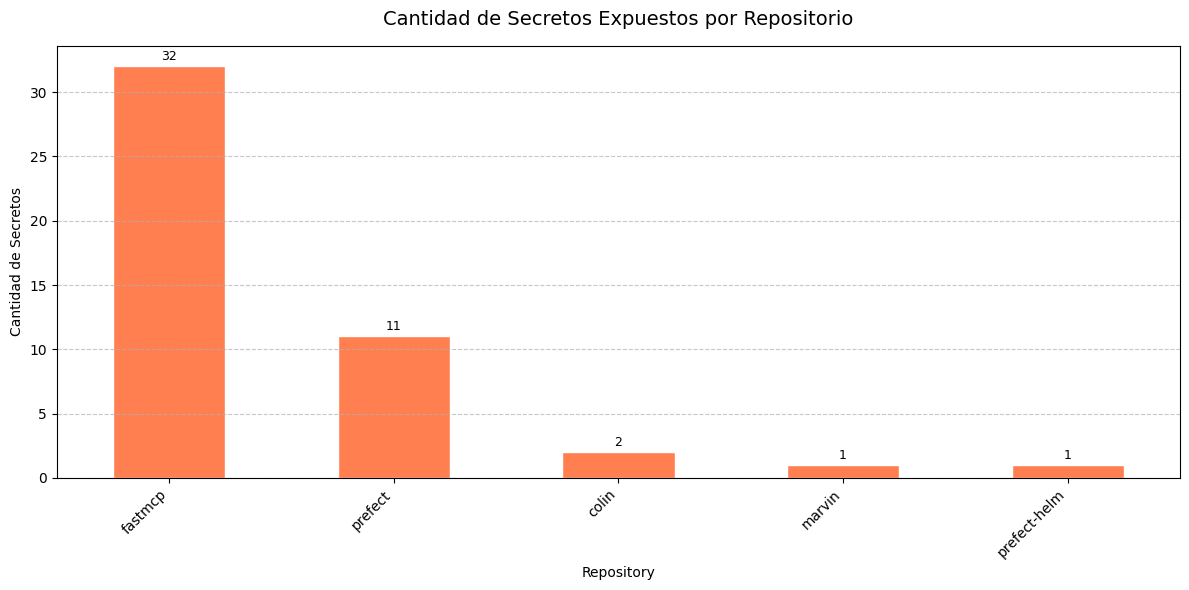

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer el CSV recopilatorio
# Envolver en un try-except en caso de que no haya encontrado secretos antes
try:
    df_analisis = pd.read_csv('../results/resumen_todos_secretos.csv')
    
    # 2. Generar el conteo por Repositorio
    conteo_por_repo = df_analisis['Repository'].value_counts()
    
    # 3. Imprimir el texto bruto
    print("=== SECRETOS EXPUESTOS POR REPOSITORIO ===\n")
    print(conteo_por_repo.to_string())
    print(f"Name: count, dtype: {conteo_por_repo.dtype}\n")
    
    # 4. Configurar y generar el gráfico
    plt.figure(figsize=(12, 6))
    
    # Color coral/naranja
    ax = conteo_por_repo.plot(kind='bar', color='#ff7f50', edgecolor='white')
    
    # Estilos del gráfico
    plt.title('Cantidad de Secretos Expuestos por Repositorio', fontsize=14, pad=15)
    plt.ylabel('Cantidad de Secretos', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    
    # Añadir valores exactos sobre cada barra para mayor claridad
    for i, v in enumerate(conteo_por_repo):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("No se encontró el archivo CSV. Asegúrate de ejecutar la Celda 1 primero.")

=== ANÁLISIS CUANTITATIVO DE SECRETOS EXPUESTOS ===
Total de hallazgos analizados: 11

1. Distribución por Tipo de Secreto (RuleID):
   - generic-api-key: 7 hallazgos (63.6%)
   - private-key: 4 hallazgos (36.4%)

2. Distribución por Ubicación de Archivos:
   - Pruebas (tests/): 8 hallazgos (72.7%)
   - Documentación (docs/): 2 hallazgos (18.2%)
   - Interfaz (ui-v2/): 1 hallazgos (9.1%)

3. Entropía Promedio (Nivel de aleatoriedad):
   - generic-api-key: 4.04
   - private-key: 5.71


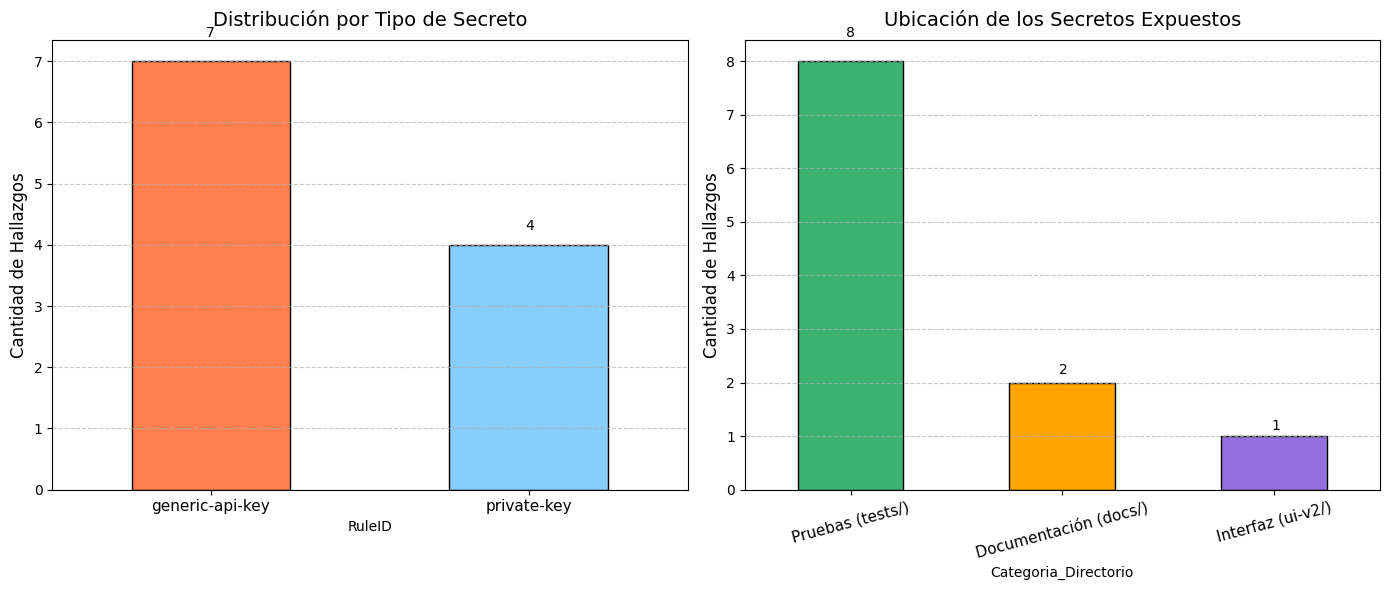

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Cargar los datos del archivo JSON (ajusta la ruta según tu estructura)
ruta_json = '../results/prefect_secrets.json' 

try:
    with open(ruta_json, 'r') as f:
        datos = json.load(f)
        
    df = pd.DataFrame(datos)
    total_secretos = len(df)
    
    print("=== ANÁLISIS CUANTITATIVO DE SECRETOS EXPUESTOS ===")
    print(f"Total de hallazgos analizados: {total_secretos}\n")

    # 2. Distribución por Tipo de Secreto (RuleID)
    print("1. Distribución por Tipo de Secreto (RuleID):")
    conteo_reglas = df['RuleID'].value_counts()
    porcentajes_reglas = df['RuleID'].value_counts(normalize=True) * 100

    for regla in conteo_reglas.index:
        cantidad = conteo_reglas[regla]
        porcentaje = porcentajes_reglas[regla]
        print(f"   - {regla}: {cantidad} hallazgos ({porcentaje:.1f}%)")
    print()

    # 3. Categorización de Archivos por Directorio
    def categorizar_directorio(ruta_archivo):
        if 'tests/' in ruta_archivo:
            return 'Pruebas (tests/)'
        elif 'docs/' in ruta_archivo:
            return 'Documentación (docs/)'
        elif 'ui-v2/' in ruta_archivo:
            return 'Interfaz (ui-v2/)'
        else:
            return 'Otros / Código'

    # Aplicar la función para crear una nueva columna
    df['Categoria_Directorio'] = df['File'].apply(categorizar_directorio)
    
    print("2. Distribución por Ubicación de Archivos:")
    conteo_categorias = df['Categoria_Directorio'].value_counts()
    porcentajes_categorias = df['Categoria_Directorio'].value_counts(normalize=True) * 100
    
    for categoria in conteo_categorias.index:
        cantidad = conteo_categorias[categoria]
        porcentaje = porcentajes_categorias[categoria]
        print(f"   - {categoria}: {cantidad} hallazgos ({porcentaje:.1f}%)")
    print()

    # 4. Entropía Promedio por Tipo de Secreto
    print("3. Entropía Promedio (Nivel de aleatoriedad):")
    entropia_promedio = df.groupby('RuleID')['Entropy'].mean()
    
    for regla in entropia_promedio.index:
        media = entropia_promedio[regla]
        print(f"   - {regla}: {media:.2f}")

    # ==========================================
    # 5. GENERACIÓN DE GRÁFICOS
    # ==========================================
    
    # Crear una figura con 1 fila y 2 columnas para los gráficos
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # Colores personalizados
    colores_reglas = ['#ff7f50', '#87cefa']
    colores_categorias = ['#3cb371', '#ffa500', '#9370db', '#c0c0c0']

    # Gráfico 1: Tipo de Secreto
    ax1 = conteo_reglas.plot(kind='bar', ax=axes[0], color=colores_reglas, edgecolor='black')
    axes[0].set_title('Distribución por Tipo de Secreto', fontsize=14, pad=10)
    axes[0].set_ylabel('Cantidad de Hallazgos', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0, labelsize=11)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Añadir las etiquetas de valor sobre las barras
    for p in ax1.patches:
        ax1.annotate(str(p.get_height()), (p.get_x() * 1.005 + p.get_width() / 2., p.get_height() * 1.05), ha='center', va='bottom')

    # Gráfico 2: Ubicación de Archivos
    ax2 = conteo_categorias.plot(kind='bar', ax=axes[1], color=colores_categorias[:len(conteo_categorias)], edgecolor='black')
    axes[1].set_title('Ubicación de los Secretos Expuestos', fontsize=14, pad=10)
    axes[1].set_ylabel('Cantidad de Hallazgos', fontsize=12)
    axes[1].tick_params(axis='x', rotation=15, labelsize=11)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    # Añadir las etiquetas de valor sobre las barras
    for p in ax2.patches:
        ax2.annotate(str(p.get_height()), (p.get_x() * 1.005 + p.get_width() / 2., p.get_height() * 1.05), ha='center', va='bottom')

    # Ajustar el diseño y mostrar
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{ruta_json}'. Verifica que el archivo exista y la ruta sea correcta.")
except KeyError as e:
    print(f"Error: El archivo JSON no tiene la estructura esperada. Falta la clave {e}.")